In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs


In [2]:
# Create fake customer data with 4 natural groups
X, y_true = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.8,
    random_state=42
)

# Convert to dataframe with meaningful column names
df = pd.DataFrame(X, columns=['credit_score', 'financial_stress_score'])

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (300, 2)
   credit_score  financial_stress_score
0     -9.205816                6.643647
1     -9.526658                7.015878
2     -1.851162                8.037611
3     -7.053772               -6.001088
4    -10.468827                6.517054


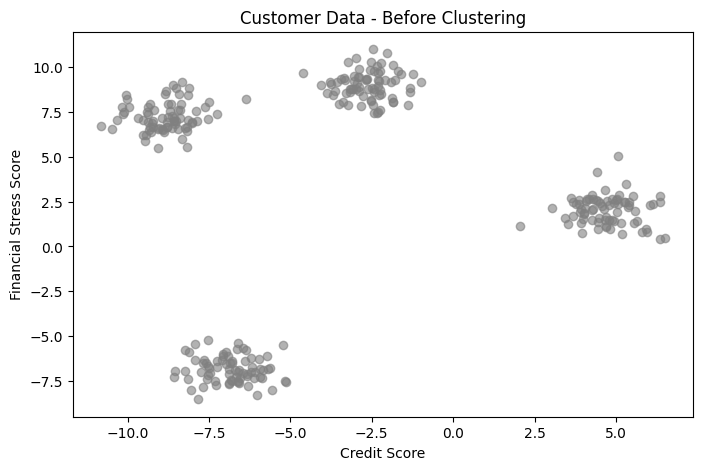

In [3]:
plt.figure(figsize=(8,5))
plt.scatter(df['credit_score'], df['financial_stress_score'], 
            alpha=0.6, color='gray')
plt.title('Customer Data - Before Clustering')
plt.xlabel('Credit Score')
plt.ylabel('Financial Stress Score')
plt.show()

In [4]:
# Scale the data first
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Run K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add cluster labels back to dataframe
df['cluster'] = kmeans.labels_

print("Cluster counts:")
print(df['cluster'].value_counts())

Cluster counts:
cluster
3    75
0    75
1    75
2    75
Name: count, dtype: int64


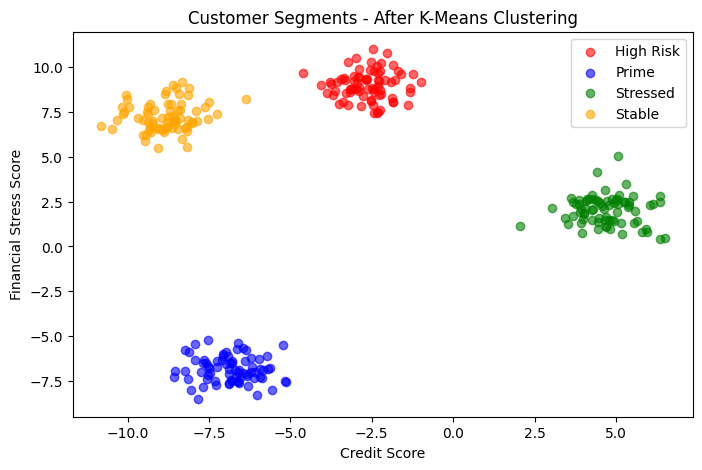

In [6]:
plt.figure(figsize=(8,5))
colors = ['red', 'blue', 'green', 'orange']
labels = ['High Risk', 'Prime', 'Stressed', 'Stable']

for i in range(4):
    mask = df['cluster'] == i
    plt.scatter(df[mask]['credit_score'], 
                df[mask]['financial_stress_score'],
                color=colors[i], label=labels[i], alpha=0.6)

plt.title('Customer Segments - After K-Means Clustering')
plt.xlabel('Credit Score')
plt.ylabel('Financial Stress Score')
plt.legend()
plt.show()